# Финальная проверка устойчивости RNN

В этом ноутбуке проверяем устойчивость финальных RNN-кандидатов. Новые RNN здесь не обучаются: используем эмбеддинги из `10_capacity_sweep` и повторяем оценку XGBoost на нескольких random seed.

## План

1. Зафиксировать те же prefix метки и baseline-признаки, что в `05` и `10`.
2. Взять финальные кандидаты: `GRU h128`, `GRU h256 l1`, `GRU h256 l2`, `LSTM h128`.
3. Для каждого random seed посчитать `Baseline`, `Embedding only`, `Baseline + Embedding`.
4. Агрегировать test ROC-AUC и PR-AUC как `mean ± std`.
5. Выбрать финальный RNN-кандидат не по одному случайному прогону, а по устойчивому результату.

## 1. Setup

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import pandas as pd
import polars as pl
import seaborn as sns

from src.data import load_prepared_sequences
from src.downstream import build_base_meta, build_baseline_features, build_meta_for_prefix, evaluate_xgboost_feature_set
from src.splits import apply_user_split, load_user_split

sns.set_theme(style='whitegrid')
pl.Config.set_tbl_rows(40)
pl.Config.set_tbl_cols(30)


def to_pandas_safe(df: pl.DataFrame) -> pd.DataFrame:
    return pd.DataFrame(df.to_dicts())

In [2]:
ARTIFACTS_DIR = PROJECT_ROOT / 'artifacts'
DATA_DIR = ARTIFACTS_DIR / 'data'
CAPACITY_DIR = ARTIFACTS_DIR / 'capacity_sweep'
OUT_DIR = ARTIFACTS_DIR / 'final_stability'
FIGURES_DIR = OUT_DIR / 'figures'

for path in [OUT_DIR, FIGURES_DIR]:
    path.mkdir(parents=True, exist_ok=True)

PREFIX_LEN = 150
TOP_K_EVENTS = 10
POOLING = 'max'
HORIZONS = {'retention_7d': 7, 'retention_14d': 14}
SEEDS = [11, 42, 77, 123, 202]
CLEAN_EVENTS_GLOB = str(DATA_DIR / 'clean_events' / '*.parquet')
SPLIT_PATH = DATA_DIR / 'split.json'
SPLIT_USERS_PATH = DATA_DIR / 'split_users.parquet'

candidate_paths = {
    'GRU h128 l1 max': CAPACITY_DIR / 'embeddings' / 'gru_h128_l1_ref_max_prefix150.parquet',
    'GRU h256 l1 max': CAPACITY_DIR / 'embeddings' / 'gru_h256_l1_max_prefix150.parquet',
    'GRU h256 l2 max': CAPACITY_DIR / 'embeddings' / 'gru_h256_l2_d02_max_prefix150.parquet',
    'LSTM h128 l1 max': CAPACITY_DIR / 'embeddings' / 'lstm_h128_l1_ref_max_prefix150.parquet',
}

missing = [str(path) for path in candidate_paths.values() if not path.exists()]
if missing:
    raise FileNotFoundError(f'Missing candidate embeddings: {missing}')

pl.DataFrame([{'candidate': name, 'path': str(path)} for name, path in candidate_paths.items()])

candidate,path
str,str
"""GRU h128 l1 max""","""/Users/fedornikonov/hse_recsys…"
"""GRU h256 l1 max""","""/Users/fedornikonov/hse_recsys…"
"""GRU h256 l2 max""","""/Users/fedornikonov/hse_recsys…"
"""LSTM h128 l1 max""","""/Users/fedornikonov/hse_recsys…"


## 2. Метки и baseline-признаки

Здесь используется тот же честный prefix protocol: признаки и эмбеддинги строятся по первым `150` событиям, а метка считается только для пользователей с полностью наблюдаемым horizon.

In [3]:
prepared = load_prepared_sequences(DATA_DIR)
split = load_user_split(SPLIT_PATH)
split_prepared = apply_user_split(prepared, split)
train_prepared = split_prepared['train']
split_users = pl.read_parquet(SPLIT_USERS_PATH)

base_meta, data_end_ts = build_base_meta(CLEAN_EVENTS_GLOB, prepared.user_ids)
meta, label_summary_df = build_meta_for_prefix(base_meta, prefix_len=PREFIX_LEN, horizons=HORIZONS, data_end_ts=data_end_ts)
baseline_df, baseline_cols, baseline_summary_df = build_baseline_features(
    prepared,
    train_prepared,
    split_users,
    meta,
    prefix_len=PREFIX_LEN,
    top_k_events=TOP_K_EVENTS,
    horizons=HORIZONS,
)

label_summary_df.write_csv(OUT_DIR / 'stability_label_summary.csv')
baseline_summary_df.write_csv(OUT_DIR / 'stability_baseline_summary.csv')
label_summary_df

prefix_len,label,valid_users,positive_rate
i64,str,i64,f64
150,"""retention_7d""",18547,0.281124
150,"""retention_14d""",15207,0.181758


### Вывод по данным

Размер valid-когорта совпадает с предыдущими ноутбуками для `prefix_len=150`. Поэтому проверка устойчивости проверяет именно устойчивость downstream learner, а не меняет постановку задачи.

## 3. Повторные downstream-прогоны

In [4]:
rows = []

for seed in SEEDS:
    print(f'=== seed={seed} ===')
    for label_name in HORIZONS:
        baseline_metrics = evaluate_xgboost_feature_set(
            baseline_df,
            baseline_cols,
            label_name,
            'Baseline',
            seed=seed,
        ).with_columns(
            pl.lit(seed).alias('seed'),
            pl.lit('Baseline').alias('candidate'),
            pl.lit('baseline').alias('feature_group'),
            pl.lit(len(baseline_cols)).alias('num_features'),
        )
        rows.append(baseline_metrics)

    for candidate_name, embeddings_path in candidate_paths.items():
        embeddings_df = pl.read_parquet(embeddings_path)
        embedding_cols = [col for col in embeddings_df.columns if col.startswith('emb_')]
        joined_df = baseline_df.join(embeddings_df, on='appmetrica_device_id', how='inner')

        for label_name in HORIZONS:
            emb_metrics = evaluate_xgboost_feature_set(
                joined_df,
                embedding_cols,
                label_name,
                candidate_name,
                seed=seed,
            ).with_columns(
                pl.lit(seed).alias('seed'),
                pl.lit(candidate_name).alias('candidate'),
                pl.lit('embedding').alias('feature_group'),
                pl.lit(len(embedding_cols)).alias('num_features'),
            )
            combo_metrics = evaluate_xgboost_feature_set(
                joined_df,
                [*baseline_cols, *embedding_cols],
                label_name,
                f'Baseline + {candidate_name}',
                seed=seed,
            ).with_columns(
                pl.lit(seed).alias('seed'),
                pl.lit(candidate_name).alias('candidate'),
                pl.lit('baseline_plus_embedding').alias('feature_group'),
                pl.lit(len(baseline_cols) + len(embedding_cols)).alias('num_features'),
            )
            rows.extend([emb_metrics, combo_metrics])

stability_metrics_df = pl.concat(rows, how='vertical_relaxed')
stability_metrics_df.write_csv(OUT_DIR / 'stability_metrics.csv')
stability_metrics_df

=== seed=11 ===
=== seed=42 ===
=== seed=77 ===
=== seed=123 ===
=== seed=202 ===


feature_set,label,split,roc_auc,pr_auc,num_users,seed,candidate,feature_group,num_features
str,str,str,f64,f64,i64,i32,str,str,i32
"""Baseline""","""retention_7d""","""val""",0.647298,0.461698,2783,11,"""Baseline""","""baseline""",15
"""Baseline""","""retention_7d""","""test""",0.658513,0.451784,2805,11,"""Baseline""","""baseline""",15
"""Baseline""","""retention_14d""","""val""",0.704512,0.341481,2318,11,"""Baseline""","""baseline""",15
"""Baseline""","""retention_14d""","""test""",0.676279,0.334018,2303,11,"""Baseline""","""baseline""",15
"""GRU h128 l1 max""","""retention_7d""","""val""",0.673891,0.478703,2783,11,"""GRU h128 l1 max""","""embedding""",128
"""GRU h128 l1 max""","""retention_7d""","""test""",0.680615,0.474187,2805,11,"""GRU h128 l1 max""","""embedding""",128
"""Baseline + GRU h128 l1 max""","""retention_7d""","""val""",0.668826,0.473632,2783,11,"""GRU h128 l1 max""","""baseline_plus_embedding""",143
"""Baseline + GRU h128 l1 max""","""retention_7d""","""test""",0.673996,0.486045,2805,11,"""GRU h128 l1 max""","""baseline_plus_embedding""",143
"""GRU h128 l1 max""","""retention_14d""","""val""",0.686489,0.354865,2318,11,"""GRU h128 l1 max""","""embedding""",128


In [5]:
test_metrics_df = stability_metrics_df.filter(pl.col('split') == 'test')
stability_summary_df = (
    test_metrics_df
    .group_by(['label', 'candidate', 'feature_group'], maintain_order=True)
    .agg(
        pl.col('roc_auc').mean().alias('roc_auc_mean'),
        pl.col('roc_auc').std().alias('roc_auc_std'),
        pl.col('pr_auc').mean().alias('pr_auc_mean'),
        pl.col('pr_auc').std().alias('pr_auc_std'),
        pl.col('num_users').first().alias('num_users'),
        pl.col('num_features').first().alias('num_features'),
    )
    .sort(['label', 'feature_group', 'roc_auc_mean'], descending=[False, False, True])
)
stability_summary_df.write_csv(OUT_DIR / 'stability_summary.csv')
stability_summary_df

label,candidate,feature_group,roc_auc_mean,roc_auc_std,pr_auc_mean,pr_auc_std,num_users,num_features
str,str,str,f64,f64,f64,f64,i64,i32
"""retention_14d""","""Baseline""","""baseline""",0.678765,0.002705,0.341181,0.004305,2303,15
"""retention_14d""","""GRU h256 l1 max""","""baseline_plus_embedding""",0.705074,0.003216,0.364406,0.003728,2303,271
"""retention_14d""","""LSTM h128 l1 max""","""baseline_plus_embedding""",0.699052,0.001709,0.367123,0.005231,2303,143
"""retention_14d""","""GRU h128 l1 max""","""baseline_plus_embedding""",0.697491,0.005024,0.359924,0.004078,2303,143
"""retention_14d""","""GRU h256 l2 max""","""baseline_plus_embedding""",0.695695,0.00324,0.36133,0.004292,2303,271
"""retention_14d""","""GRU h256 l1 max""","""embedding""",0.704286,0.001192,0.367561,0.006857,2303,256
"""retention_14d""","""LSTM h128 l1 max""","""embedding""",0.697582,0.004946,0.359053,0.004392,2303,128
"""retention_14d""","""GRU h128 l1 max""","""embedding""",0.696552,0.004843,0.359282,0.004871,2303,128
"""retention_14d""","""GRU h256 l2 max""","""embedding""",0.694282,0.005707,0.362246,0.006726,2303,256


In [6]:
best_by_group_df = (
    stability_summary_df
    .sort(['label', 'feature_group', 'roc_auc_mean'], descending=[False, False, True])
    .group_by(['label', 'feature_group'], maintain_order=True)
    .head(3)
)
best_by_group_df.write_csv(OUT_DIR / 'stability_best_by_group.csv')
best_by_group_df

label,feature_group,candidate,roc_auc_mean,roc_auc_std,pr_auc_mean,pr_auc_std,num_users,num_features
str,str,str,f64,f64,f64,f64,i64,i32
"""retention_14d""","""baseline""","""Baseline""",0.678765,0.002705,0.341181,0.004305,2303,15
"""retention_14d""","""baseline_plus_embedding""","""GRU h256 l1 max""",0.705074,0.003216,0.364406,0.003728,2303,271
"""retention_14d""","""baseline_plus_embedding""","""LSTM h128 l1 max""",0.699052,0.001709,0.367123,0.005231,2303,143
"""retention_14d""","""baseline_plus_embedding""","""GRU h128 l1 max""",0.697491,0.005024,0.359924,0.004078,2303,143
"""retention_14d""","""embedding""","""GRU h256 l1 max""",0.704286,0.001192,0.367561,0.006857,2303,256
"""retention_14d""","""embedding""","""LSTM h128 l1 max""",0.697582,0.004946,0.359053,0.004392,2303,128
"""retention_14d""","""embedding""","""GRU h128 l1 max""",0.696552,0.004843,0.359282,0.004871,2303,128
"""retention_7d""","""baseline""","""Baseline""",0.660948,0.00222,0.455125,0.004181,2805,15
"""retention_7d""","""baseline_plus_embedding""","""GRU h256 l1 max""",0.69217,0.005192,0.49775,0.002296,2805,271


### Вывод по метрики устойчивости

Повторение XGBoost на пяти random seed стабилизирует вывод из `10`. В режиме «Baseline + эмбеддинг» кандидат `GRU h256 l1 max` становится лучшим по ROC-AUC на обоих горизонтах: `0.6922 ± 0.0052` для `retention_7d` и `0.7051 ± 0.0032` для `retention_14d`. Он также даёт лучший PR-AUC на `retention_7d` (`0.4978 ± 0.0023`). На `retention_14d` `LSTM h128` немного выше по PR-AUC (`0.3671 ± 0.0052`), но уступает по ROC-AUC, поэтому основным кандидатом остаётся `GRU h256 l1 max`.

## 4. Визуализация устойчивости

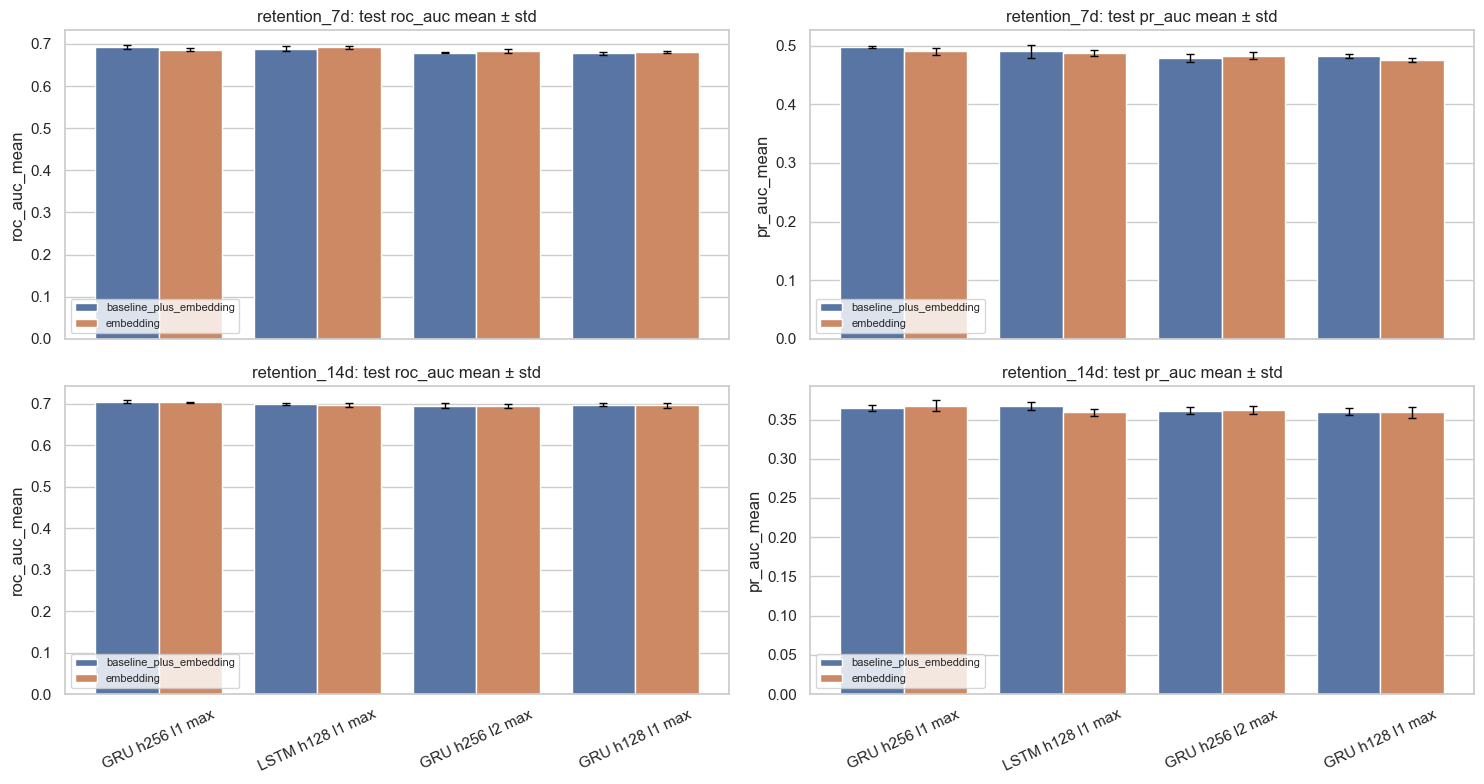

In [7]:
plot_pdf = to_pandas_safe(stability_summary_df.filter(pl.col('feature_group') != 'baseline'))
fig, axes = plt.subplots(2, 2, figsize=(15, 8), sharex=True)
for row_idx, label_name in enumerate(['retention_7d', 'retention_14d']):
    for col_idx, metric_name in enumerate(['roc_auc', 'pr_auc']):
        ax = axes[row_idx, col_idx]
        subset = plot_pdf[plot_pdf['label'] == label_name].copy()
        mean_col = f'{metric_name}_mean'
        std_col = f'{metric_name}_std'
        sns.barplot(data=subset, x='candidate', y=mean_col, hue='feature_group', ax=ax)
        for container, group_name in zip(ax.containers, subset['feature_group'].drop_duplicates()):
            group_subset = subset[subset['feature_group'] == group_name]
            for bar, (_, item) in zip(container, group_subset.iterrows()):
                height = bar.get_height()
                ax.errorbar(
                    bar.get_x() + bar.get_width() / 2,
                    height,
                    yerr=item[std_col],
                    color='black',
                    capsize=3,
                    linewidth=1,
                )
        ax.set_title(f'{label_name}: test {metric_name} mean ± std')
        ax.set_xlabel('')
        ax.tick_params(axis='x', rotation=25)
        ax.legend(fontsize=8, frameon=True)
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'stability_metrics.png', dpi=180)
plt.show()

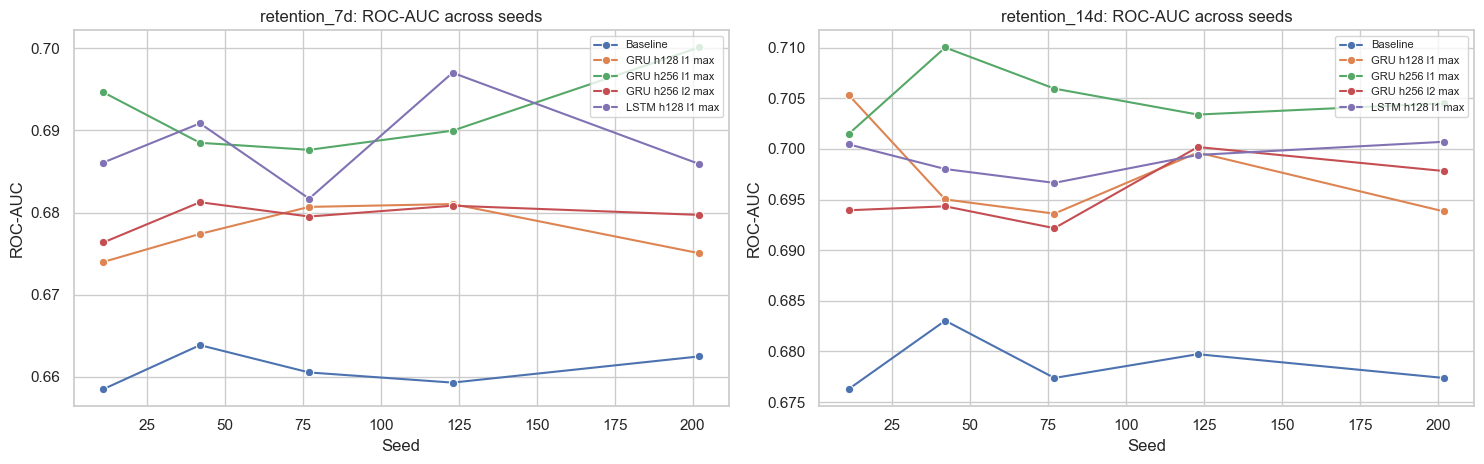

In [8]:
seed_plot_pdf = to_pandas_safe(
    test_metrics_df.filter(
        (pl.col('feature_group') == 'baseline_plus_embedding') |
        ((pl.col('feature_group') == 'baseline') & (pl.col('candidate') == 'Baseline'))
    )
)
fig, axes = plt.subplots(1, 2, figsize=(15, 4.8), sharey=False)
for ax, label_name in zip(axes, ['retention_7d', 'retention_14d']):
    subset = seed_plot_pdf[seed_plot_pdf['label'] == label_name]
    sns.lineplot(data=subset, x='seed', y='roc_auc', hue='candidate', marker='o', ax=ax)
    ax.set_title(f'{label_name}: ROC-AUC across seeds')
    ax.set_xlabel('Seed')
    ax.set_ylabel('ROC-AUC')
    ax.legend(fontsize=8, frameon=True)
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'stability_seed_lines.png', dpi=180)
plt.show()

## 5. Финальный выбор кандидата

Финальное решение принимаем по агрегированной таблице, а не по одному random seed. Основной кандидат должен быть хорошим одновременно на `retention_7d` и `retention_14d`, не иметь большого разброса и не быть чрезмерно сложным без downstream-выигрыша.

In [9]:
final_candidates_df = stability_summary_df.filter(
    (pl.col('feature_group') == 'baseline_plus_embedding') |
    ((pl.col('feature_group') == 'baseline') & (pl.col('candidate') == 'Baseline'))
).sort(['label', 'roc_auc_mean'], descending=[False, True])
final_candidates_df.write_csv(OUT_DIR / 'final_candidate_summary.csv')
final_candidates_df

label,candidate,feature_group,roc_auc_mean,roc_auc_std,pr_auc_mean,pr_auc_std,num_users,num_features
str,str,str,f64,f64,f64,f64,i64,i32
"""retention_14d""","""GRU h256 l1 max""","""baseline_plus_embedding""",0.705074,0.003216,0.364406,0.003728,2303,271
"""retention_14d""","""LSTM h128 l1 max""","""baseline_plus_embedding""",0.699052,0.001709,0.367123,0.005231,2303,143
"""retention_14d""","""GRU h128 l1 max""","""baseline_plus_embedding""",0.697491,0.005024,0.359924,0.004078,2303,143
"""retention_14d""","""GRU h256 l2 max""","""baseline_plus_embedding""",0.695695,0.00324,0.36133,0.004292,2303,271
"""retention_14d""","""Baseline""","""baseline""",0.678765,0.002705,0.341181,0.004305,2303,15
"""retention_7d""","""GRU h256 l1 max""","""baseline_plus_embedding""",0.69217,0.005192,0.49775,0.002296,2805,271
"""retention_7d""","""LSTM h128 l1 max""","""baseline_plus_embedding""",0.688321,0.005846,0.490414,0.010716,2805,143
"""retention_7d""","""GRU h256 l2 max""","""baseline_plus_embedding""",0.679544,0.001922,0.47851,0.006684,2805,271
"""retention_7d""","""GRU h128 l1 max""","""baseline_plus_embedding""",0.677641,0.003197,0.482451,0.004145,2805,143


In [10]:
for label_name in HORIZONS:
    label_df = final_candidates_df.filter(pl.col('label') == label_name).sort('roc_auc_mean', descending=True)
    best = label_df.row(0, named=True)
    print(
        label_name,
        best['candidate'],
        f"ROC-AUC={best['roc_auc_mean']:.4f}±{best['roc_auc_std']:.4f}",
        f"PR-AUC={best['pr_auc_mean']:.4f}±{best['pr_auc_std']:.4f}",
    )

retention_7d GRU h256 l1 max ROC-AUC=0.6922±0.0052 PR-AUC=0.4978±0.0023
retention_14d GRU h256 l1 max ROC-AUC=0.7051±0.0032 PR-AUC=0.3644±0.0037


## Итог

Проверка устойчивости подтвердила вывод из `10`: самым сильным финальным RNN-кандидатом становится `GRU h256, 1 layer, max pooling` в режиме «Baseline + эмбеддинг».

На `retention_7d` он даёт ROC-AUC `0.6922 ± 0.0052` и PR-AUC `0.4978 ± 0.0023`. Это выше baseline (`0.6609 ± 0.0022`, PR-AUC `0.4551 ± 0.0042`) и выше раннего кандидата `GRU h128 l1 max + baseline` (`0.6776 ± 0.0032`, PR-AUC `0.4825 ± 0.0041`). Ближайший конкурент — `LSTM h128 l1 max + baseline` с ROC-AUC `0.6883 ± 0.0058`, но у него выше разброс и ниже PR-AUC (`0.4904 ± 0.0107`).

На `retention_14d` `GRU h256 l1 max + baseline` также лучший по ROC-AUC: `0.7051 ± 0.0032`, PR-AUC `0.3644 ± 0.0037`. Базовая модель остаётся заметно ниже (`0.6788 ± 0.0027`, PR-AUC `0.3412 ± 0.0043`). `LSTM h128` немного выше по PR-AUC (`0.3671 ± 0.0052`), но уступает по ROC-AUC (`0.6991 ± 0.0017`), поэтому как основной кандидат он менее убедителен.

Важный исследовательский вывод: двухслойный `GRU h256` был лучшим по next-event prediction в `10`, но по устойчивому downstream он хуже однослойного `GRU h256`. Значит, увеличение sequence capacity не монотонно улучшает пользовательские эмбеддинги для удержания. Для финальной RNN-ветки фиксируем `GRU h256 l1 max` как основной эмбеддинг, а `LSTM h128` можно оставить как сильный дополнительный baseline.